# Heart Disease Classification Using Machine Learning: A Comparative Study of Logistic Regression, Random Forest, and SVM

## Summary

This report develops and evaluates machine-learning models for predicting heart disease from a clinical dataset. The data were first inspected for quality issues, with missing values checked and duplicate records removed before model development.

Three classifiers were then compared: Logistic Regression, Random Forest, and Support Vector Machine. Performance was assessed using accuracy, precision, recall, and F1-score, with particular attention to recall because missed positive cases are especially undesirable in a medical setting.

During hyperparameter tuning, recall was prioritised, which initially favoured SVM. However, evaluation on the held-out test set showed that this recall-first choice produced a weaker overall balance, especially in F1-score. After comparing all tuned models on unseen data, Random Forest was selected as the final model because it retained high recall while providing the best overall balance of performance.

Overall, the report presents a complete machine learning workflow, from preprocessing and model comparison to final model selection, and shows why model choice should be based not only on recall but on the broader pattern of test-set performance.

## Data Loading 
The dataset was loaded using pandas and initial inspection was performed to understand its structure and basic characteristics.   
The dataset contains 1190 observations and 12 columns, including both numerical and categorical variables.

In [1]:
import pandas as pd

df = pd.read_csv("heart_disease_data.csv")

# Display the first 5 rows to inspect the structure of the dataset
print(df.head(5))

   age  sex  chest pain type  resting bp s  cholesterol  fasting blood sugar  \
0   40    1                2           140          289                    0   
1   49    0                3           160          180                    0   
2   37    1                2           130          283                    0   
3   48    0                4           138          214                    0   
4   54    1                3           150          195                    0   

   resting ecg  max heart rate  exercise angina  oldpeak  ST slope  target  
0            0             172                0      0.0         1       0  
1            0             156                0      1.0         2       1  
2            1              98                0      0.0         1       0  
3            0             108                1      1.5         2       1  
4            0             122                0      0.0         1       0  


`df.head()` is used to inspect the overall structure of the dataset, verify that column names are correct, and confirm that the target variable is present.

In [2]:
# Show column names, data types, and non-null counts for an initial data quality check
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   int64  
 1   sex                  1190 non-null   int64  
 2   chest pain type      1190 non-null   int64  
 3   resting bp s         1190 non-null   int64  
 4   cholesterol          1190 non-null   int64  
 5   fasting blood sugar  1190 non-null   int64  
 6   resting ecg          1190 non-null   int64  
 7   max heart rate       1190 non-null   int64  
 8   exercise angina      1190 non-null   int64  
 9   oldpeak              1190 non-null   float64
 10  ST slope             1190 non-null   int64  
 11  target               1190 non-null   int64  
dtypes: float64(1), int64(11)
memory usage: 111.7 KB
None


`df.info()` provides an overview of the dataset, including data types and non-null counts for each column, which helps identify potential missing values and verify data consistency

In [3]:
# Generate summary statistics for numerical variables
print(df.describe())

               age          sex  chest pain type  resting bp s  cholesterol  \
count  1190.000000  1190.000000      1190.000000   1190.000000  1190.000000   
mean     53.720168     0.763866         3.232773    132.153782   210.363866   
std       9.358203     0.424884         0.935480     18.368823   101.420489   
min      28.000000     0.000000         1.000000      0.000000     0.000000   
25%      47.000000     1.000000         3.000000    120.000000   188.000000   
50%      54.000000     1.000000         4.000000    130.000000   229.000000   
75%      60.000000     1.000000         4.000000    140.000000   269.750000   
max      77.000000     1.000000         4.000000    200.000000   603.000000   

       fasting blood sugar  resting ecg  max heart rate  exercise angina  \
count          1190.000000  1190.000000     1190.000000      1190.000000   
mean              0.213445     0.698319      139.732773         0.387395   
std               0.409912     0.870359       25.517636     

`df.describe()` summarises the statistical distribution of numerical features, including measures such as mean, standard deviation, and quartiles, which help in understanding the scale and variability of the data.

## Data Preprocessing

The dataset appears consistent based on the initial inspection using `df.info()`. However, it is also necessary to check for duplicate records, as they may introduce bias and affect model performance. Therefore, duplicate entries will be identified and removed.

### Missing Values and Duplicate Check

The dataset was checked for both standard missing values and common placeholder tokens used to represent missing data. No missing values were detected. Duplicate rows were also examined before further preprocessing.

In [4]:
# Standard missing-value check
print(df.isnull().sum())

# Check common placeholder tokens for hidden missing values
for token in ["", "?", "NA", "null", "None"]:
    print(f"Count of '{token}':")
    print((df.astype(str) == token).sum())
    print()

# Check duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64
Count of '':
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Count of '?':
age                    0
sex                    0
chest pain type        0
resting bp s           0
cholesterol            0
fasting blood sugar    0
resting ecg            0
max heart rate         0
exercise angina        0
oldpeak                0
ST slope               0
target                 0
dtype: int64

Count of 'NA':
age              

A total of 272 duplicate records were identified. Duplicate records were removed to prevent repeated observations from biasing the model, as identical samples may lead to over-representation of certain patterns in the training data.

In [5]:
df = df.drop_duplicates() # Remove duplicate records to ensure data quality and avoid redundancy.
len(df) #Verify that duplicate records have been successfully removed by checking the dataset size.

918

After removing duplicates, the dataset size was reduced from 1190 to 918 observations.

### Categorical encoding
Categorical variables were first identified and encoded to ensure compatibility with machine learning models. These variables were transformed into binary indicator features using one-hot encoding. For example, the variable chest pain type, originally represented by values such as 1, 2, 3, and 4, is converted into multiple binary columns.
- chest pain type_1
- chest pain type_2
- chest pain type_3
- chest pain type_4

This prevents the model from incorrectly interpreting categorical values as having an ordinal or numerical relationship (e.g., treating 4 as twice as large as 2).

One-hot encoding was chosen to avoid introducing artificial ordinal relationships between categorical values, which could mislead the model.

In [6]:
# Define categorical variables that should be treated as categories 
# And it is because their numeric values represent labels or classes rather than continuous measurements. 
categorical_cols = [
    "sex",
    "chest pain type",
    "fasting blood sugar",
    "resting ecg",
    "exercise angina",
    "ST slope"
]


# Apply one-hot encoding to convert categorical variables into machine-readable binary features
df_encoded = pd.get_dummies(df, columns=categorical_cols)

After encoding, the feature matrix (X) and target variable (y) were separated, followed by splitting the dataset into training and testing sets.

In [7]:
X = df_encoded.drop("target", axis=1)
y = df_encoded["target"]

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, # 20% of the data is allocated to the test set.
    random_state = 1,# This sets a random seed to ensure reproducibility of the results.
    stratify = y,# The `stratify` parameter ensures that the class distribution of the target variable is preserved in both the training and testing sets.
)

An 80/20 train-test split was adopted to balance model development with final evaluation. This provides enough data for training while reserving a representative held-out set for an unbiased assessment of generalisation.

Stratified sampling was used so that the class distribution in the training and test sets remained close to that of the full dataset.

Dataset-level cleaning steps such as duplicate removal were carried out before the split because they do not use information from the test labels. Any feature scaling required by Logistic Regression and SVM was then performed inside Pipeline objects during cross-validation and fitting, which helps prevent data leakage.

In [9]:
# Check whether the sample sizes are reasonable after stratified splitting.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print()

print("y overall distribution:")
print(y.value_counts(normalize=True))
print()

print("y_train distribution:")
print(y_train.value_counts(normalize=True))
print()

print("y_test distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (734, 22)
X_test shape: (184, 22)

y overall distribution:
target
1    0.553377
0    0.446623
Name: proportion, dtype: float64

y_train distribution:
target
1    0.553134
0    0.446866
Name: proportion, dtype: float64

y_test distribution:
target
1    0.554348
0    0.445652
Name: proportion, dtype: float64


By comparing the distributions of the target variable in the training and testing sets with the overall dataset, it can be observed that they are closely aligned. This indicates that the stratified split has preserved the original class distribution, leading to more reliable model evaluation.

Next, 5-fold stratified cross-validation was applied only to the training data to compare Logistic Regression, Random Forest, and SVM. The required libraries are imported below.

In [10]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [11]:
# Define a 5-fold cross-validation strategy.
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
# n_splits=5: splits the training data into 5 folds, using 4 for fitting and 1 for validation in each round.
# shuffle=True: shuffles the observations before assigning them to folds so the split does not depend on the original row order.
# random_state=1: fixes the random seed so the shuffled folds are reproducible.

## Model Training

After splitting the training data, three models were selected for comparison: Logistic Regression (LR), Random Forest (RF), and Support Vector Machine (SVM). These models represent different learning paradigms. Logistic Regression serves as a simple and interpretable baseline. Random Forest is an ensemble method capable of capturing non-linear relationships. SVM is a margin-based classifier that performs well in high-dimensional spaces.

Logistic Regression is sensitive to feature scaling, and standardisation improves optimisation stability, convergence speed, and prevents features with larger magnitudes from dominating the learning process.

For SVM, feature scaling is essential, as it relies on distance-based calculations. Without scaling, features with larger values may dominate and negatively affect model performance.

In contrast, Random Forest is not sensitive to feature scaling, as it is based on decision trees.

The RBF kernel was selected for SVM because it allows the model to capture non-linear relationships by constructing flexible decision boundaries.

The parameter C controls the trade-off between classification accuracy and generalisation. A larger C reduces training errors but may lead to overfitting, while a smaller C improves generalisation by allowing some misclassification.

Pipelines were used to combine preprocessing and modelling steps into a single workflow. This ensures that scaling is applied correctly within each cross-validation fold, preventing data leakage.

The initial hyperparameters were selected based on commonly used default or reasonable baseline values, providing a starting point before further optimisation.

These models serve as baseline configurations, which will later be refined through systematic hyperparameter tuning.

In [12]:
# Logistic Regression with standardisation
lr_model = Pipeline([ 
    ("scaler", StandardScaler()), # StandardScaler is used to standardise the features.
    ("lr", LogisticRegression(max_iter=1000, random_state=1,C = 1.0))
    # The parameter max_iter=1000 sets the maximum number of iterations for the optimisation algorithm.
    # random_state: parameter ensures reproducibility by fixing the random seed.
])

# Random Forest without standardisation
rf_model = RandomForestClassifier( 
    n_estimators=100,# The parameter n_estimators=100 specifies that the model uses 100 decision trees.
    max_depth=5,# The parameter max_depth=5 limits the maximum depth of each tree to 5 levels.
    random_state=1# The random_state=1 ensures reproducibility of the model.
)

# SVM with standardisation
svm_model = Pipeline([
    ("scaler", StandardScaler()),# StandardScaler is applied to standardise each feature.
    ("svm", SVC(kernel="rbf", C=1.0))
    #kernel: The kernel parameter determines how the decision boundary is constructed. 
])

### Evaluation Metrics

Model performance was assessed using four metrics: accuracy, precision, recall, and F1-score.

Accuracy measures the overall proportion of correct predictions, but it may be misleading when class distributions are uneven or when false negatives are particularly important.

Precision measures how many predicted positive cases are actually positive, while recall measures how many actual positive cases are correctly identified.

In this task, recall is especially relevant because failing to detect heart disease cases may have more serious consequences than producing false alarms. However, relying only on recall may increase false positives. For this reason, F1-score was also considered, as it provides a balance between precision and recall.

Taken together, these metrics provide a more complete evaluation of classification performance than any single metric alone.

In [13]:
# Evaluation metrics used for model comparison
# accuracy: overall correctness
# precision: proportion of predicted positives that are correct
# recall: proportion of actual positives correctly identified
# f1: harmonic mean of precision and recall
scoring = ["accuracy", "precision", "recall", "f1"]

### Cross-Validation Performance

Stratified K-Fold cross-validation was applied to evaluate model performance on the training data. This approach ensures that each fold preserves the class distribution, providing a more reliable estimate of generalisation performance.

In [14]:
# Perform cross-validation on the training data only
# estimator (first argument): the model or pipeline being evaluated
# X_train, y_train: training features and labels
# cv=skf: use the stratified 5-fold splitter defined above
# scoring=scoring: compute the selected metrics for each fold
# return_train_score stays at its default False, so only validation scores are returned
# The output is a dictionary containing one score array per metric
lr_cv = cross_validate(lr_model, X_train, y_train, cv=skf, scoring=scoring)
rf_cv = cross_validate(rf_model, X_train, y_train, cv=skf, scoring=scoring)
svm_cv = cross_validate(svm_model, X_train, y_train, cv=skf, scoring=scoring)

In [15]:
# Summarise cross-validation results
# Compute mean and standard deviation across folds
# This provides a stable estimate of model performance
cv_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],

    "Accuracy Mean": [
        lr_cv["test_accuracy"].mean(),
        rf_cv["test_accuracy"].mean(),
        svm_cv["test_accuracy"].mean()
    ],
    "Accuracy Std": [
        lr_cv["test_accuracy"].std(),
        rf_cv["test_accuracy"].std(),
        svm_cv["test_accuracy"].std()
    ],

    "Precision Mean": [
        lr_cv["test_precision"].mean(),
        rf_cv["test_precision"].mean(),
        svm_cv["test_precision"].mean()
    ],
    "Recall Mean": [
        lr_cv["test_recall"].mean(),
        rf_cv["test_recall"].mean(),
        svm_cv["test_recall"].mean()
    ],
    "F1 Mean": [
        lr_cv["test_f1"].mean(),
        rf_cv["test_f1"].mean(),
        svm_cv["test_f1"].mean()
    ]
})

print(cv_results)

                 Model  Accuracy Mean  Accuracy Std  Precision Mean  \
0  Logistic Regression       0.861019      0.035700        0.868345   
1        Random Forest       0.870543      0.034003        0.860717   
2                  SVM       0.871932      0.030856        0.867654   

   Recall Mean   F1 Mean  
0     0.881632  0.874509  
1     0.913701  0.886277  
2     0.906323  0.886388  


The cross-validation results show that all three models achieve comparable performance in terms of accuracy and F1-score.

Random Forest achieves slightly higher accuracy, while SVM demonstrates higher recall compared to the other models. This indicates that SVM is more effective at identifying positive cases, which is consistent with the objective of minimising false negatives.

However, the overall differences between the models are relatively small, suggesting that further performance improvements may be achieved through hyperparameter tuning.

### Hyperparameter Tuning

To improve model performance, hyperparameter tuning was conducted using GridSearchCV. This method systematically evaluates combinations of parameter values using cross-validation and selects the configuration that maximises the chosen evaluation metric.

In this study, recall was used as the primary scoring metric during tuning, as it prioritises minimising false negatives, which is particularly important in medical classification tasks.

As the model is implemented using a pipeline consisting of a scaler and a logistic regression classifier, hyperparameters must be specified using the format "step__parameter".

The parameter `C` in Logistic Regression controls the strength of regularisation, reflecting the trade-off between bias and variance. Smaller values of `C` impose stronger regularisation, promoting simpler models with higher bias, while larger values allow more complex decision boundaries at the risk of overfitting.

In [16]:
# Define hyperparameter grid for Logistic Regression
lr_param_grid = {
    "lr__C": [0.01, 0.1, 1, 10]
}

# GridSearchCV performs exhaustive search over parameter combinations
# estimator: the model or pipeline to be tuned
# param_grid: the candidate hyperparameter values to search over
# cv=skf: evaluate each candidate with stratified 5-fold cross-validation
# scoring="recall": choose the best setting using recall because sensitivity is prioritised
# n_jobs=-1: use all available CPU cores in parallel
# refit=True is left as the default, so the best model is retrained on the full training set
from sklearn.model_selection import GridSearchCV

lr_grid = GridSearchCV(
    estimator=lr_model,
    param_grid=lr_param_grid,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

lr_grid.fit(X_train, y_train)

print("Best LR params:", lr_grid.best_params_)
print("Best LR CV recall:", lr_grid.best_score_)

Best LR params: {'lr__C': 0.01}
Best LR CV recall: 0.9013550135501355


In [17]:
# Define hyperparameter grid for Random Forest
rf_param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [3, 5, 10, None]
}

rf_grid = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV recall:", rf_grid.best_score_)

Best RF params: {'max_depth': 3, 'n_estimators': 50}
Best RF CV recall: 0.9161698283649503


In [18]:
# Define hyperparameter grid for SVM
# Note: parameter name must match pipeline step ("svm__C")
svm_param_grid = {
    "svm__C": [0.1, 1, 10]
}

svm_grid = GridSearchCV(
    estimator=svm_model,
    param_grid=svm_param_grid,
    cv=skf,
    scoring="recall",
    n_jobs=-1
)

svm_grid.fit(X_train, y_train)

print("Best SVM params:", svm_grid.best_params_)
print("Best SVM CV recall:", svm_grid.best_score_)

Best SVM params: {'svm__C': 0.1}
Best SVM CV recall: 0.9285155073772959


In [19]:
tuning_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Best Params": [
        lr_grid.best_params_,
        rf_grid.best_params_,
        svm_grid.best_params_
    ],
    "Best CV Recall": [
        lr_grid.best_score_,
        rf_grid.best_score_,
        svm_grid.best_score_
    ]
})

print(tuning_results)

                 Model                           Best Params  Best CV Recall
0  Logistic Regression                       {'lr__C': 0.01}        0.901355
1        Random Forest  {'max_depth': 3, 'n_estimators': 50}        0.916170
2                  SVM                       {'svm__C': 0.1}        0.928516


The tuning results show that SVM achieves the highest cross-validation recall after optimisation, so it was taken forward as the initial preferred model when sensitivity was prioritised.

Random Forest also performs strongly and remains close to SVM, while Logistic Regression gives slightly lower recall. At this stage, the results justify selecting SVM first, but they do not yet establish it as the best overall model because the final decision must still be checked on the held-out test set.

In [20]:
# Retrieve the best SVM model from GridSearchCV
# This model is already configured with optimal hyperparameters
best_svm = svm_grid.best_estimator_

# Refit on full training data
best_svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",0.1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [21]:
# Evaluate the initially selected recall-first SVM on the held-out test set
y_pred_svm = best_svm.predict(X_test)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Initial SVM Test Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Initial SVM Test Precision:", precision_score(y_test, y_pred_svm))
print("Initial SVM Test Recall   :", recall_score(y_test, y_pred_svm))
print("Initial SVM Test F1-score :", f1_score(y_test, y_pred_svm))

Initial SVM Test Accuracy : 0.8206521739130435
Initial SVM Test Precision: 0.7948717948717948
Initial SVM Test Recall   : 0.9117647058823529
Initial SVM Test F1-score : 0.8493150684931506


Evaluating the initially selected SVM on the held-out test set confirms that the recall-first tuning strategy succeeds in detecting most positive cases.

However, its lower precision and lower F1-score indicate that this gain in sensitivity comes with more false positives and a weaker overall balance. For that reason, the other tuned models were also re-evaluated on the same test set before making the final model choice.

### Test Set Performance

To further evaluate model performance, all tuned models were assessed on the held-out test set.

The results show that SVM achieves the highest recall, confirming its strong ability to identify positive cases. However, this comes at the cost of lower precision and accuracy compared to Logistic Regression and Random Forest.

In contrast, Logistic Regression and Random Forest demonstrate more balanced performance across all metrics, particularly in terms of accuracy and precision.

In [22]:
# Define best lr and rf model
best_lr = lr_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [23]:
# Predict train results
y_pred_lr = best_lr.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [24]:
final_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "SVM"],
    "Test Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_svm)
    ],
    "Test Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_svm)
    ],
    "Test Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_svm)
    ],
    "Test F1": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_svm)
    ]
})

print(final_comparison)

                 Model  Test Accuracy  Test Precision  Test Recall   Test F1
0  Logistic Regression       0.842391        0.834862     0.892157  0.862559
1        Random Forest       0.842391        0.828829     0.901961  0.863850
2                  SVM       0.820652        0.794872     0.911765  0.849315


Comparing the tuned models on the held-out test set makes the trade-off clearer. SVM achieves the highest recall, but it also records the lowest precision, the lowest accuracy, and the lowest F1-score among the three tuned models.

Random Forest retains very high recall while achieving the best F1-score and matching the best test accuracy. Logistic Regression is also well balanced, but Random Forest gives the strongest overall compromise between sensitivity and general classification performance.

Therefore, Random Forest was selected as the final model for the remaining analysis and interpretation.

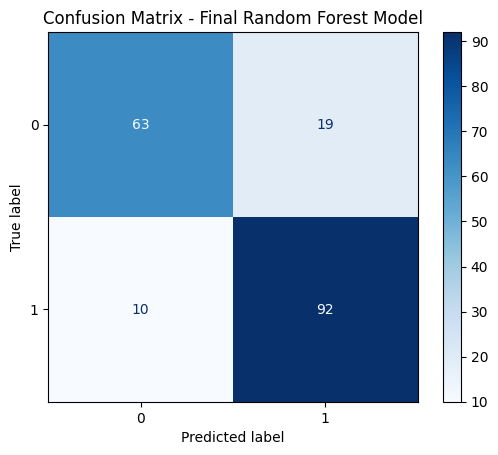

In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Final Random Forest Model")
plt.show()

The confusion matrix of the final Random Forest model supports this choice. Most positive cases are correctly identified, so false negatives remain relatively low, while the number of false positives is still more controlled than in the recall-driven SVM result.

This indicates that Random Forest preserves strong sensitivity without sacrificing overall balance to the same extent.

The comparative bar chart summarises the same pattern visually. SVM leads on recall, but Random Forest stays close on recall while performing better overall on F1-score and matching the top test accuracy.

This visual comparison therefore supports the final decision to use Random Forest rather than a purely recall-optimised SVM.

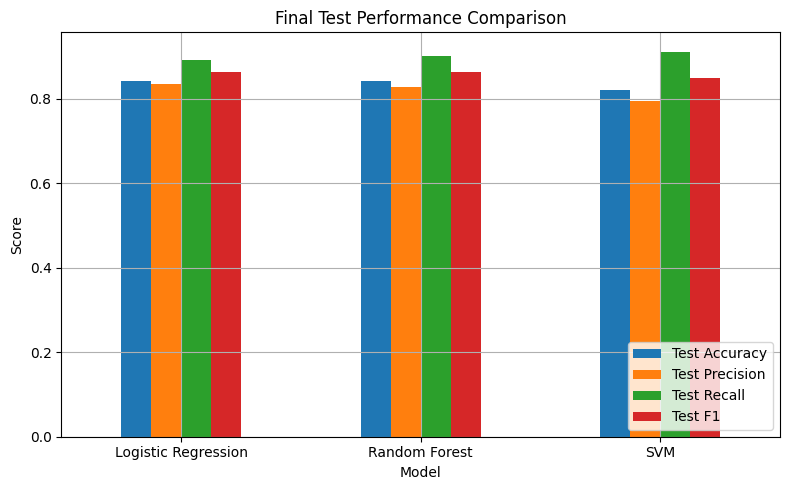

In [26]:
final_comparison.set_index("Model")[["Test Accuracy", "Test Precision", "Test Recall", "Test F1"]].plot(
    kind="bar", figsize=(8,5)
)
plt.ylabel("Score")
plt.title("Final Test Performance Comparison")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.grid(True)
plt.show()

## Conclusion
This report developed and evaluated Logistic Regression, Random Forest, and SVM models for heart disease classification using a structured machine-learning workflow.

After data inspection and duplicate removal, the dataset was split into stratified training and test sets. The models were then compared with accuracy, precision, recall, and F1-score, with recall given particular importance because missed positive cases are especially undesirable in a medical setting.

Prioritising recall during tuning initially favoured SVM, but test-set evaluation showed that this choice reduced precision and F1-score. Random Forest retained high recall while producing the best overall balance on unseen data, so it was chosen as the final model.

A limitation of this study is that only a modest set of features and a small group of classical models were considered. Future work could explore richer feature engineering, threshold tuning, and more advanced ensemble methods to improve clinical decision support.

## References

- McKinney, W. *pandas documentation*. Used for data loading, data inspection, missing-value checking, and duplicate removal in the preprocessing stage.

- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., and Duchesnay, E. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825–2830. Used for train_test_split, StratifiedKFold, cross_validate, GridSearchCV, Pipeline, StandardScaler, LogisticRegression, RandomForestClassifier, SVC, and evaluation metrics including accuracy, precision, recall, F1-score, and confusion matrix.

- Hunter, J. D. (2007). *Matplotlib: A 2D Graphics Environment*. Computing in Science & Engineering, 9(3), 90–95. Used for figure generation and visualisation.